In [160]:
from pathlib import Path
from pystac_client import Client
import geopandas as gpd
from shapely.geometry import mapping
import planetary_computer

## setup connection

In [161]:
URL = "https://planetarycomputer.microsoft.com/api/stac/v1"
# custom headers
headers = []
client = Client.open(URL, headers=headers)
client

<Client id=microsoft-pc>

## Check all the data collection available in the stack url

In [162]:
for collection in client.get_collections():
    print(collection.id)

daymet-annual-pr
daymet-daily-hi
3dep-seamless
3dep-lidar-dsm
fia
gridmet
daymet-annual-na
daymet-monthly-na
daymet-annual-hi
daymet-monthly-hi
daymet-monthly-pr
gnatsgo-tables
hgb
cop-dem-glo-30
cop-dem-glo-90
terraclimate
nasa-nex-gddp-cmip6
gpm-imerg-hhr
gnatsgo-rasters
3dep-lidar-hag
io-lulc-annual-v02
goes-cmi
conus404
sentinel-1-rtc
3dep-lidar-intensity
3dep-lidar-pointsourceid
mtbs
noaa-c-cap
3dep-lidar-copc
modis-64A1-061
alos-fnf-mosaic
3dep-lidar-returns
mobi
landsat-c2-l2
chloris-biomass
kaza-hydroforecast
planet-nicfi-analytic
modis-17A2H-061
modis-11A2-061
daymet-daily-pr
predicted-damage-venezuela-2026
3dep-lidar-dtm-native
3dep-lidar-classification
3dep-lidar-dtm
gap
modis-17A2HGF-061
planet-nicfi-visual
gbif
modis-17A3HGF-061
modis-09A1-061
alos-dem
alos-palsar-mosaic
deltares-water-availability
modis-16A3GF-061
modis-21A2-061
us-census
jrc-gsw
deltares-floods
modis-43A4-061
modis-09Q1-061
modis-14A1-061
hrea
modis-13Q1-061
modis-14A2-061
sentinel-2-l2a
modis-15A2H-061


## or search collection by name

In [163]:
collection_search = client.collection_search(q='GRD')
for result in collection_search.collections():
    print(result.id)

d:\Personal Projects\STACK_API\pySTACK_Client\.venv\Lib\site-packages\pystac_client\collection_search.py:306: UserWarning: Server does not conform to COLLECTION_SEARCH. Filtering will be performed client-side where only bbox, datetime, and q arguments are supported
  warnings.warn(


sentinel-1-rtc
sentinel-1-grd


## Inspect about the metadeta of the collection

In [164]:
collection = client.get_collection('sentinel-1-grd')
collection

<CollectionClient id=sentinel-1-grd>

## To filter out desired data we have to perform filters. The scripts below provides list of queryables 

In [165]:
queryables = collection.get_queryables()
list(queryables["properties"].keys())

['id',
 'datetime',
 'geometry',
 'platform',
 's1:shape',
 'end_datetime',
 'constellation',
 's1:resolution',
 's1:datatake_id',
 'start_datetime',
 's1:orbit_source',
 's1:slice_number',
 's1:total_slices',
 'sar:looks_range',
 'sat:orbit_state',
 'sar:product_type',
 'sar:looks_azimuth',
 'sar:polarizations',
 'sar:frequency_band',
 'sat:absolute_orbit',
 'sat:relative_orbit',
 's1:processing_level',
 'sar:instrument_mode',
 'sar:center_frequency',
 'sar:resolution_range',
 's1:product_timeliness',
 'sar:resolution_azimuth',
 'sar:pixel_spacing_range',
 'sar:observation_direction',
 'sar:pixel_spacing_azimuth',
 'sar:looks_equivalent_number',
 's1:instrument_configuration_ID',
 'sat:platform_international_designator']

In [166]:
# AOI
MAIN_DIR = Path.cwd().parent   # parent of current working directory
gpkg_path = MAIN_DIR / "input_data" / "vectors" / "146247.gpkg"
if gpkg_path.exists():
    gdf = gpd.read_file(gpkg_path)
else:
    raise FileExistsError ("Please provide a valid file path")

## for stack search gdf needs in EPSG: 4326
if gdf.crs != "EPSG:4326":
    gdf = gdf.to_crs(epsg=4226)
AOI_id = 0
AOI = gdf.geometry.iloc[AOI_id]
geometry = mapping(AOI)

## Search the items in the collections
# https://pystac-client.readthedocs.io/en/latest/tutorials/cql2-filter.html
# https://developmentseed.org/cql2-rs/latest/playground/

## Item Search
When the Catalog is a STAC API, we have the ability to search for items based on spatio-temporal properties.

Get the items (items doesn't contain data itself, its stores metadeta and storage url)

### this is CQL2 Json
filter = {"op": "<=", "args": [{"property": "eo:cloud_cover"}, 10]}
### this is CQL2 Text
filter = "eo:cloud_cover<=60 and eo:cloud_cover>=40"
### to construct CQL2 text to json visit this website
https://developmentseed.org/cql2-rs/latest/playground/

In [167]:

search_instance = client.search(collections=['sentinel-2-l2a'],
    datetime='2026-01-01/2026-02-01',
    intersects=geometry,
    filter='eo:cloud_cover<=50'
    )
# get the items from instance
items = list(search_instance.items())

# get the signed items so that we can fetch data from cloud without errors
signed_items = [planetary_computer.sign(item) for item in items]
signed_items

[<Item id=S2C_MSIL2A_20260130T052051_R062_T43PFR_20260130T100710>,
 <Item id=S2B_MSIL2A_20260125T052009_R062_T43PFR_20260125T090625>,
 <Item id=S2C_MSIL2A_20260120T052131_R062_T43PFR_20260120T083615>,
 <Item id=S2B_MSIL2A_20260115T052049_R062_T43PFR_20260115T090435>,
 <Item id=S2C_MSIL2A_20260110T052211_R062_T43PFR_20260110T082921>,
 <Item id=S2B_MSIL2A_20260105T052119_R062_T43PFR_20260105T074657>]

## Visualize the tif boundary and aoi

In [168]:
from copy import deepcopy

import pandas as pd
from shapely.geometry import shape


# convert a list of STAC Items into a GeoDataFrame
def items_to_geodataframe(items):
    _items = []
    for i in items:
        i = i.to_dict()
        _i = deepcopy(i)
        _i["geometry"] = shape(_i["geometry"])
        _items.append(_i)
    gdf = gpd.GeoDataFrame(pd.json_normalize(_items))
    for field in ["properties.datetime", "properties.created", "properties.updated"]:
        if field in gdf:
            gdf[field] = pd.to_datetime(gdf[field])
    gdf.set_index("properties.datetime", inplace=True)
    return gdf

In [169]:
# convert found items to a GeoDataFrame
items_gdf = items_to_geodataframe(signed_items)
items_gdf.head()

,type,stac_version,stac_extensions,id,geometry,bbox,links,collection,properties.platform,properties.instruments,...,assets.datastrip-metadata.roles,assets.tilejson.href,assets.tilejson.type,assets.tilejson.title,assets.tilejson.roles,assets.rendered_preview.href,assets.rendered_preview.type,assets.rendered_preview.title,assets.rendered_preview.rel,assets.rendered_preview.roles
properties.datetime,,,,,,,,,,,,,,,,,,,,,
2026-01-30 05:20:51.025000+00:00,Feature,1.1.0,[https://stac-extensions.github.io/eo/v1.1.0/s...,S2C_MSIL2A_20260130T052051_R062_T43PFR_2026013...,"POLYGON ((75.92789 14.471, 76.9464 14.46478, 7...","[75.9239229, 13.4725398, 76.9464047, 14.4710005]","[{'rel': 'collection', 'href': 'https://planet...",sentinel-2-l2a,Sentinel-2C,[msi],...,[metadata],https://planetarycomputer.microsoft.com/api/da...,application/json,TileJSON with default rendering,[tiles],https://planetarycomputer.microsoft.com/api/da...,image/png,Rendered preview,preview,[overview]
2026-01-25 05:20:09.024000+00:00,Feature,1.1.0,[https://stac-extensions.github.io/eo/v1.1.0/s...,S2B_MSIL2A_20260125T052009_R062_T43PFR_2026012...,"POLYGON ((75.92789 14.471, 76.9464 14.46478, 7...","[75.9239229, 13.4725398, 76.9464047, 14.4710005]","[{'rel': 'collection', 'href': 'https://planet...",sentinel-2-l2a,Sentinel-2B,[msi],...,[metadata],https://planetarycomputer.microsoft.com/api/da...,application/json,TileJSON with default rendering,[tiles],https://planetarycomputer.microsoft.com/api/da...,image/png,Rendered preview,preview,[overview]
2026-01-20 05:21:31.025000+00:00,Feature,1.1.0,[https://stac-extensions.github.io/eo/v1.1.0/s...,S2C_MSIL2A_20260120T052131_R062_T43PFR_2026012...,"POLYGON ((75.92789 14.471, 76.9464 14.46478, 7...","[75.9239229, 13.4725398, 76.9464047, 14.4710005]","[{'rel': 'collection', 'href': 'https://planet...",sentinel-2-l2a,Sentinel-2C,[msi],...,[metadata],https://planetarycomputer.microsoft.com/api/da...,application/json,TileJSON with default rendering,[tiles],https://planetarycomputer.microsoft.com/api/da...,image/png,Rendered preview,preview,[overview]
2026-01-15 05:20:49.024000+00:00,Feature,1.1.0,[https://stac-extensions.github.io/eo/v1.1.0/s...,S2B_MSIL2A_20260115T052049_R062_T43PFR_2026011...,"POLYGON ((75.92789 14.471, 76.9464 14.46478, 7...","[75.9239229, 13.4725398, 76.9464047, 14.4710005]","[{'rel': 'collection', 'href': 'https://planet...",sentinel-2-l2a,Sentinel-2B,[msi],...,[metadata],https://planetarycomputer.microsoft.com/api/da...,application/json,TileJSON with default rendering,[tiles],https://planetarycomputer.microsoft.com/api/da...,image/png,Rendered preview,preview,[overview]
2026-01-10 05:22:11.025000+00:00,Feature,1.1.0,[https://stac-extensions.github.io/eo/v1.1.0/s...,S2C_MSIL2A_20260110T052211_R062_T43PFR_2026011...,"POLYGON ((75.92789 14.471, 76.9464 14.46478, 7...","[75.9239229, 13.4725398, 76.9464047, 14.4710005]","[{'rel': 'collection', 'href': 'https://planet...",sentinel-2-l2a,Sentinel-2C,[msi],...,[metadata],https://planetarycomputer.microsoft.com/api/da...,application/json,TileJSON with default rendering,[tiles],https://planetarycomputer.microsoft.com/api/da...,image/png,Rendered preview,preview,[overview]


In [170]:
list(items_gdf.columns)

['type',
 'stac_version',
 'stac_extensions',
 'id',
 'geometry',
 'bbox',
 'links',
 'collection',
 'properties.platform',
 'properties.instruments',
 'properties.s2:mgrs_tile',
 'properties.constellation',
 'properties.s2:granule_id',
 'properties.eo:cloud_cover',
 'properties.s2:datatake_id',
 'properties.s2:product_uri',
 'properties.s2:datastrip_id',
 'properties.s2:product_type',
 'properties.sat:orbit_state',
 'properties.s2:datatake_type',
 'properties.s2:generation_time',
 'properties.sat:relative_orbit',
 'properties.s2:water_percentage',
 'properties.s2:mean_solar_zenith',
 'properties.s2:mean_solar_azimuth',
 'properties.s2:processing_baseline',
 'properties.s2:snow_ice_percentage',
 'properties.s2:vegetation_percentage',
 'properties.s2:thin_cirrus_percentage',
 'properties.s2:cloud_shadow_percentage',
 'properties.s2:nodata_pixel_percentage',
 'properties.s2:unclassified_percentage',
 'properties.s2:not_vegetated_percentage',
 'properties.s2:degraded_msi_data_percentage',

<Axes: xlabel='properties.datetime', ylabel='Cloud Cover percentage'>

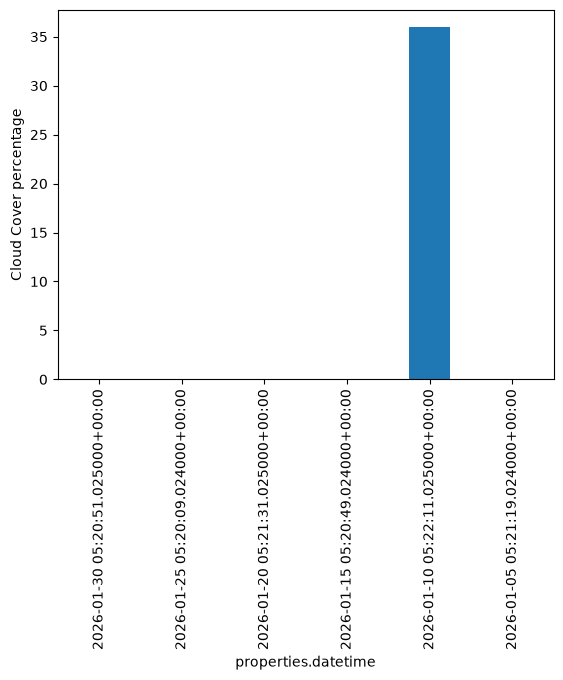

In [171]:
items_gdf['properties.eo:cloud_cover'].plot(ylabel='Cloud Cover percentage', kind='bar')

### To know more about available tiles visit
https://holoviews.org/reference/elements/bokeh/Tiles.html

and read hvplot documentation for further improvement

In [172]:
import hvplot.pandas  # noqa: F401


# plot polygons on a map with background tiles.
def plot_polygons(data, line_width=1, *args, **kwargs):
    return data.hvplot.polygons(
        *args,
        geo=True,
        projection="GOOGLE_MERCATOR",
        xaxis=None,
        yaxis=None,
        frame_width=600,
        frame_height=600,
        fill_alpha=0,
        line_width=line_width,
        **kwargs,
    )

In [173]:
plot_polygons(items_gdf, tiles="EsriImagery") * plot_polygons(gdf, line_color="red", line_width=10)

:Overlay
   .WMTS.I      :WMTS   [Longitude,Latitude]
   .Polygons.I  :Polygons   [Longitude,Latitude]
   .Polygons.II :Polygons   [Longitude,Latitude]

## Preview the rgb image

In [174]:
import matplotlib.pyplot as plt
import requests
from PIL import Image as PILImage
from io import BytesIO
def preview_rgb_tiles(item):
    url = item.assets['rendered_preview'].href
    date = item.properties['datetime']
    cloud_cover = item.properties['eo:cloud_cover']
    response = requests.get(url)
    img = PILImage.open(BytesIO(response.content))

    plt.imshow(img)
    plt.title(f"{date} \n Cloud Cover Percentage {round(cloud_cover, 4)}")
    plt.axis("off")
    plt.show()
    # return img



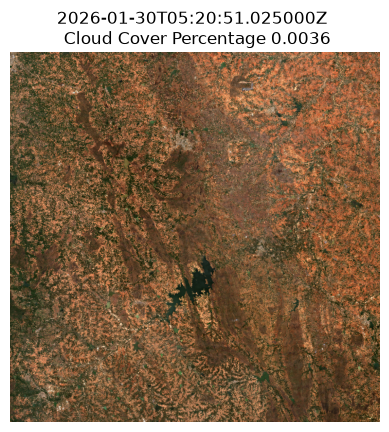

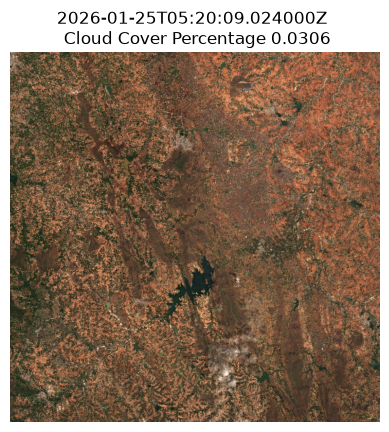

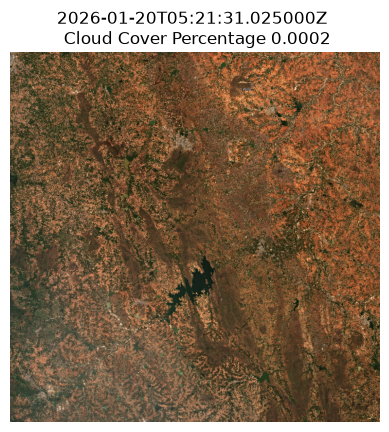

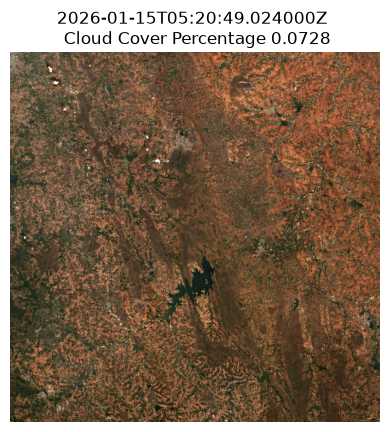

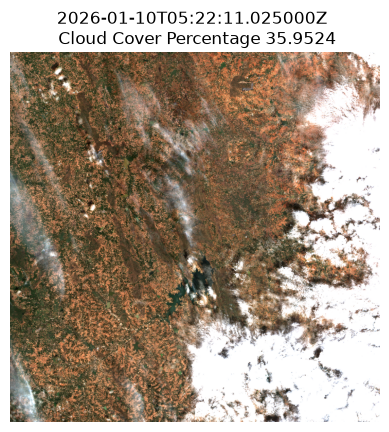

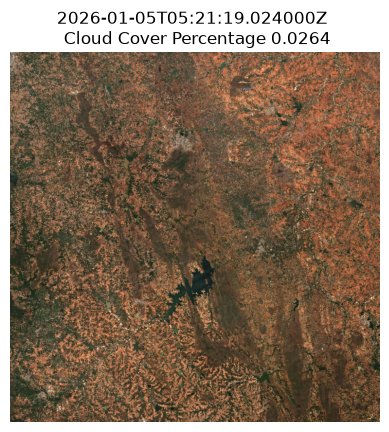

In [175]:
for item in signed_items:
    preview_rgb_tiles(item)

In [176]:
item

<Item id=S2B_MSIL2A_20260105T052119_R062_T43PFR_20260105T074657>

In [177]:
item = signed_items[0]
def get_bands_info(item):

    print(f'Band', 10*"-", 'Title')
    for band in list(item.assets.keys()):
        print(f"{band}, {item.assets[band].title}")
def get_band_info(item, band):
    print(item.assets[band].title)


In [178]:
get_band_info(item, 'B05')

Band 5 - Vegetation red edge 1 - 20m


In [179]:
get_bands_info(item)

Band ---------- Title
AOT, Aerosol optical thickness (AOT)
B01, Band 1 - Coastal aerosol - 60m
B02, Band 2 - Blue - 10m
B03, Band 3 - Green - 10m
B04, Band 4 - Red - 10m
B05, Band 5 - Vegetation red edge 1 - 20m
B06, Band 6 - Vegetation red edge 2 - 20m
B07, Band 7 - Vegetation red edge 3 - 20m
B08, Band 8 - NIR - 10m
B09, Band 9 - Water vapor - 60m
B11, Band 11 - SWIR (1.6) - 20m
B12, Band 12 - SWIR (2.2) - 20m
B8A, Band 8A - Vegetation red edge 4 - 20m
SCL, Scene classfication map (SCL)
WVP, Water vapour (WVP)
visual, True color image
safe-manifest, SAFE manifest
granule-metadata, Granule metadata
inspire-metadata, INSPIRE metadata
product-metadata, Product metadata
datastrip-metadata, Datastrip metadata
tilejson, TileJSON with default rendering
rendered_preview, Rendered preview


In [180]:
item

<Item id=S2C_MSIL2A_20260130T052051_R062_T43PFR_20260130T100710>

### As we got STACK items. Now we have load data specified path in Items. The COG data can be store in any cloud platform such as AWS S3 or Azure blob storage

In [ ]:
url_1 = item.assets['B04'].href
import rasterio
with rasterio.open(url_1) as test_src:
    print(test_src.crs)
    print(test_src.profile)
    print(test_src.res)


EPSG:32643
{'driver': 'GTiff', 'dtype': 'uint16', 'nodata': 0.0, 'width': 10980, 'height': 10980, 'count': 1, 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 43N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",75],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32643"]]'), 'transform': Affine(10.0, 0.0, 600000.0,
       0.0, -10.0, 1600020.0), 'blockxsize': 512, 'blockysize': 512, 'tiled': True, 'compress': 'deflate', 'interleave': 'band'}
(10.0, 10.0)


In [ ]:
from odc.stac import load

In [ ]:
dataset = load([item], bands=['B04', 'B08', 'SCL'] )
dataset

<xarray.Dataset> Size: 1GB
Dimensions:      (y: 10980, x: 10980, time: 1)
Coordinates:
  * y            (y) float64 88kB 1.6e+06 1.6e+06 1.6e+06 ... 1.49e+06 1.49e+06
  * x            (x) float64 88kB 6e+05 6e+05 6e+05 ... 7.098e+05 7.098e+05
  * time         (time) datetime64[us] 8B 2026-01-30T05:20:51.025000
    spatial_ref  int32 4B 32643
Data variables:
    B04          (time, y, x) float32 482MB 4.592e+03 3.78e+03 ... 3.54e+03
    B08          (time, y, x) float32 482MB 4.812e+03 4.12e+03 ... 4.604e+03
    SCL          (time, y, x) float32 482MB 5.0 5.0 5.0 5.0 ... 5.0 5.0 5.0 5.0

In [ ]:
dataset.spatial_ref

<xarray.DataArray 'spatial_ref' ()> Size: 4B
array(32643, dtype=int32)
Coordinates:
    spatial_ref  int32 4B 32643
Attributes: (12/18)
    spatial_ref:                       PROJCRS["WGS 84 / UTM zone 43N",BASEGE...
    crs_wkt:                           PROJCRS["WGS 84 / UTM zone 43N",BASEGE...
    semi_major_axis:                   6378137.0
    semi_minor_axis:                   6356752.314245179
    inverse_flattening:                298.257223563
    reference_ellipsoid_name:          WGS 84
    ...                                ...
    latitude_of_projection_origin:     0.0
    longitude_of_central_meridian:     75.0
    false_easting:                     500000.0
    false_northing:                    0.0
    scale_factor_at_central_meridian:  0.9996
    GeoTransform:                      600000 10 0 1600020 0 -10

In [ ]:
dataset.dtypes

Frozen({'B04': dtype('float32'), 'B08': dtype('float32'), 'SCL': dtype('float32')})

In [ ]:
import numpy as np

In [ ]:
np.unique(dataset.SCL.values[0])

array([ 2.,  4.,  5.,  6.,  7.,  8., 10.], dtype=float32)

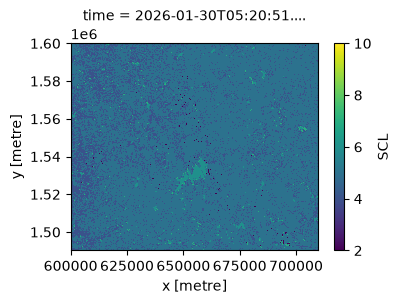

In [ ]:
dataset.SCL.plot.imshow(col='time')

In [ ]:
dataset.B04

<xarray.DataArray 'B04' (time: 1, y: 10980, x: 10980)> Size: 482MB
array([[[4592., 3780., 2194., ..., 2510., 2374., 2016.],
        [4144., 3378., 2562., ..., 2484., 2394., 2014.],
        [2786., 2588., 2520., ..., 2442., 2388., 1947.],
        ...,
        [2606., 2700., 3130., ..., 3026., 3156., 2932.],
        [2918., 2584., 2522., ..., 3192., 3100., 3326.],
        [2262., 2160., 1996., ..., 3458., 3336., 3540.]]],
      shape=(1, 10980, 10980), dtype=float32)
Coordinates:
  * time         (time) datetime64[us] 8B 2026-01-30T05:20:51.025000
  * y            (y) float64 88kB 1.6e+06 1.6e+06 1.6e+06 ... 1.49e+06 1.49e+06
  * x            (x) float64 88kB 6e+05 6e+05 6e+05 ... 7.098e+05 7.098e+05
    spatial_ref  int32 4B 32643

In [189]:
def get_utm(lat, lon):
    utm_zone = int((lon + 180) // 6) + 1

    if lat >= 0:
        epsg = 32600 + utm_zone
    else:
        epsg = 32700 + utm_zone

    utm_crs = f"EPSG:{epsg}"
    return utm_crs




In [ ]:
lat, lon = gdf.geometry[0].centroid.xy

(array('d', [76.78559107441791]), array('d', [13.68210224259792]))

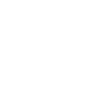

In [196]:
gdf.geometry[0]